# Exploratory Data Analysis: SME Financial Health (FHI) Classification

In [18]:
# Setup & load data (cleaned via pipeline)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.preprocessing import PreprocessConfig, preprocess_train_test

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", None)

TRAIN_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Train.csv"
TEST_PATH = "D:\\dataorg-financial-health-prediction-challenge20251204-19827-m2tn1n\\Test.csv"

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)

cfg = PreprocessConfig(id_col="ID", target_col="Target")

train, test = preprocess_train_test(train_raw, test_raw, cfg, for_model="catboost")

print("train:", train.shape, "| test:", test.shape)
train.head()

train: (9618, 47) | test: (2405, 46)


,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,business_turnover,business_age_years,motor_vehicle_insurance,has_mobile_money,current_problem_cash_flow,has_cellphone,owner_sex,offers_credit_to_customers,attitude_satisfied_with_achievement,has_credit_card,keeps_financial_records,perception_insurance_companies_dont_insure_businesses_like_yours,perception_insurance_important,has_insurance,covid_essential_service,attitude_more_successful_next_year,problem_sourcing_money,marketing_word_of_mouth,has_loan_account,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target,personal_income_missing,business_expenses_missing,business_turnover_missing,log_personal_income,log_business_expenses,log_business_turnover,business_age_total_months,business_age_months_ge_12
0,ID_3CFL0U,eswatini,63.0,yes,no,no,no,yes,3000.0,6000.0,7000.0,14.0,never had,have now,yes,yes,male,"yes, sometimes",no,never had,"yes, always",yes,yes,no,yes,yes,yes,yes,never had,never had,never had,NaN,6.0,never had,used to have but don't have now,NaN,never had,never had,Low,0,0,0,8.006701,8.699681,8.853808,174.0,0
1,ID_XWI7G3,zimbabwe,39.0,no,yes,yes,no,yes,NaN,NaN,NaN,15.0,have now,have now,NaN,yes,male,"yes, sometimes",yes,never had,"yes, always",no,yes,yes,yes,NaN,NaN,NaN,NaN,NaN,NaN,no,3.0,never had,never had,NaN,NaN,NaN,Medium,1,1,1,NaN,NaN,NaN,183.0,0
2,ID_TY93LV,malawi,34.0,don't know,no,no,don't know,yes,30000.0,6000.0,13000.0,5.0,NaN,never had,yes,yes,male,"yes, sometimes",yes,never had,no,don't know,yes,no,NaN,yes,yes,no,never had,never had,never had,yes,NaN,NaN,NaN,yes,NaN,NaN,Low,0,0,0,10.308986,8.699681,9.472782,60.0,0
3,ID_9OP2C8,malawi,28.0,yes,no,no,no,no,180000.0,60000.0,30000.0,1.0,NaN,have now,no,yes,female,"yes, sometimes",no,never had,no,no,yes,no,NaN,yes,no,no,never had,never had,never had,no,NaN,NaN,NaN,yes,never had,have now,Low,0,0,0,12.100718,11.002117,10.308986,12.0,0
4,ID_13REYS,zimbabwe,43.0,yes,no,no,yes,yes,50.0,2400.0,1800.0,3.0,never had,NaN,NaN,no,female,"yes, sometimes",yes,never had,no,yes,yes,no,no,NaN,NaN,NaN,NaN,NaN,NaN,no,0.0,never had,never had,yes,NaN,NaN,Low,0,0,0,3.931826,7.783641,7.496097,36.0,0


In [20]:
# Basic EDA overview & sanity checks

TARGET = cfg.target_col
ID = cfg.id_col

print("Target unique:", train[TARGET].unique())
print("Country unique:", train["country"].unique() if "country" in train.columns else "country not found")
print("Owner sex unique:", train["owner_sex"].unique() if "owner_sex" in train.columns else "owner_sex not found")

# Missingness summary (top 15)
missing_pct = train.isna().mean().sort_values(ascending=False) * 100
missing_pct.head(20).to_frame("missing_pct")

Target unique: <StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
Country unique: <StringArray>
['eswatini', 'zimbabwe', 'malawi', 'lesotho']
Length: 4, dtype: str
Owner sex unique: <StringArray>
['male', 'female', nan]
Length: 3, dtype: str


,missing_pct
uses_informal_lender,46.672905
uses_friends_family_savings,46.662508
motivation_make_more_money,44.614265
funeral_insurance,43.543356
medical_insurance,43.543356
business_age_months,42.742774
future_risk_theft_stock,42.628405
has_debit_card,41.619879
has_internet_banking,41.619879
has_loan_account,41.578291


## Target distribution (Overall + by country + by sex)

,count,pct
Target,,
Low,6280,65.29
Medium,2868,29.82
High,470,4.89


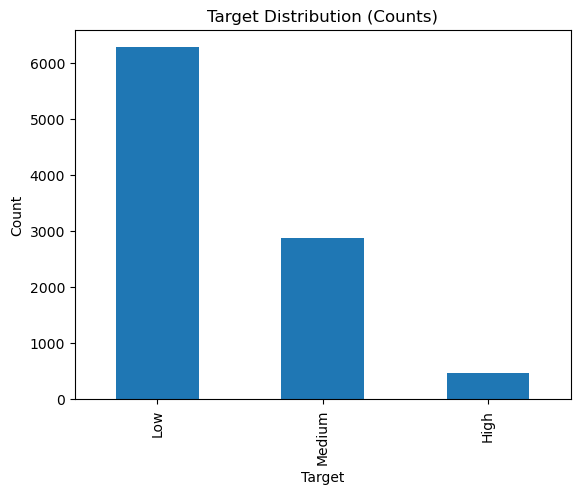

In [22]:
# Target class proportions (table + bar chart)

target_counts = train[TARGET].value_counts()
target_pct = (train[TARGET].value_counts(normalize=True) * 100).round(2)

target_table = pd.DataFrame({
    "count": target_counts,
    "pct": target_pct
})
display(target_table)

plt.figure()
target_counts.plot(kind = "bar")
plt.title("Target Distribution (Counts)")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()


What this tells us;

*- The dataset is imbalanced.*
*- Low dominates, macro-F1 will punish models that ignore Medium/High.*

Target,High,Low,Medium
country,,,
eswatini,11.48,51.42,37.10
lesotho,0.31,60.39,39.30
malawi,4.02,81.24,14.74
zimbabwe,2.34,68.57,29.10


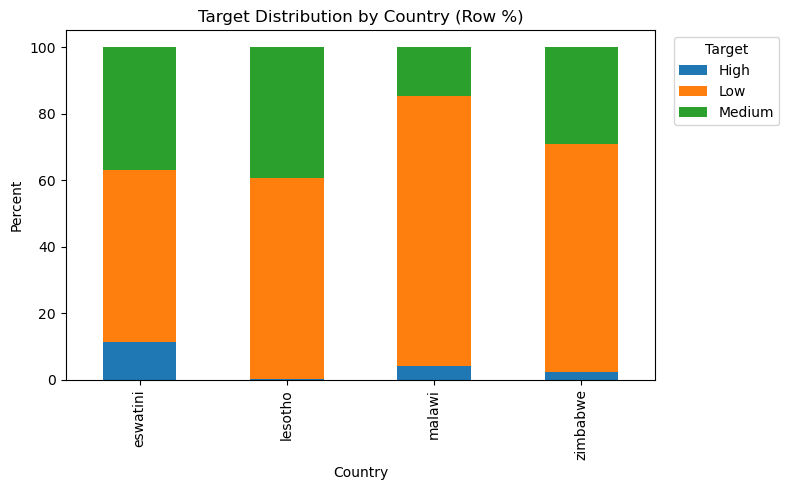

In [25]:
# Target distribution by country (stacked % bar)

if "country" in train.columns:
    ct = (
        pd.crosstab(train["country"], train[TARGET], normalize="index")
        .mul(100)
        .round(2)
    )

    display(ct)

    ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.set_title("Target Distribution by Country (Row %)")
    ax.set_xlabel("Country")
    ax.set_ylabel("Percent")
    ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

Target,High,Low,Medium
owner_sex,,,
female,5.00,66.70,28.31
male,7.39,66.33,26.28


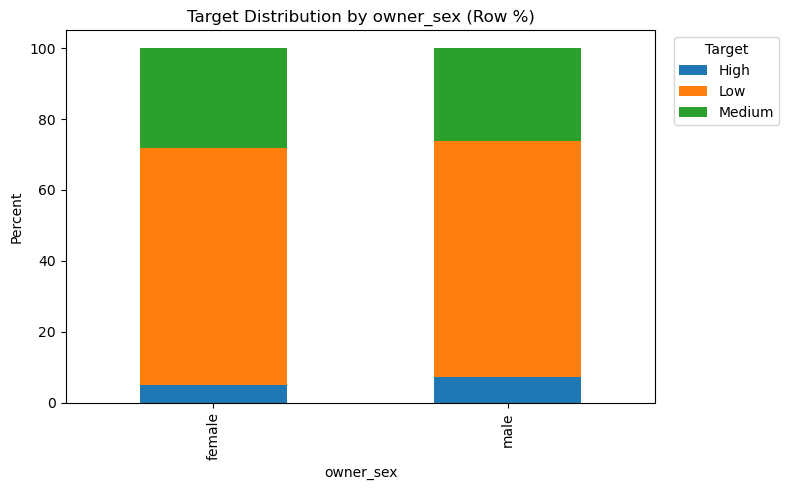

In [26]:
# Target distribution by owner_sex (stacked % bar)

if "owner_sex" in train.columns:
    ct = (
        pd.crosstab(train["owner_sex"], train[TARGET], normalize="index")
        .mul(100)
        .round(2)
    )

    display(ct)

    ax = ct.plot(kind="bar", stacked=True, figsize=(8, 5))
    ax.set_title("Target Distribution by owner_sex (Row %)")
    ax.set_xlabel("owner_sex")
    ax.set_ylabel("Percent")
    ax.legend(title="Target", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Univariate relationships (each feature vs Target)

*Done systematically with helper plotting functions.*

In [ ]:
# Helper functions (categorical plot + numeric plot)


In [8]:
# Key features: Access to finance
# These columns are strong predictors for FHI.


In [9]:
# Key features: Insurance


In [10]:
# Key features: Shocks / resilience

In [11]:
# Key features: Business scale (numeric)


In [12]:
# Business maturity

## Multivariate exploration

In [13]:
# Numeric correlation heatmap (matplotlib)


In [14]:
# Cramér’s V for categorical associations


In [15]:
# Country interactions: turnover by country


## Data drift check (Train vs Test)

In [16]:
# Category frequency drift. 
# Identify categories that appear only in test.


In [17]:
# Numeric drift using PSI (Population Stability Index)


### Hypothesis Notes